Este notebook contém oS testeS para implementação das soluções da equação de Poisson 1D e 3D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve, norm
import plotly.graph_objects as go
from scipy.interpolate import RegularGridInterpolator

N = 20  |  Condições de Contorno = [0.0, 1.0]
Erro Absoluto Global: 3.220e-15


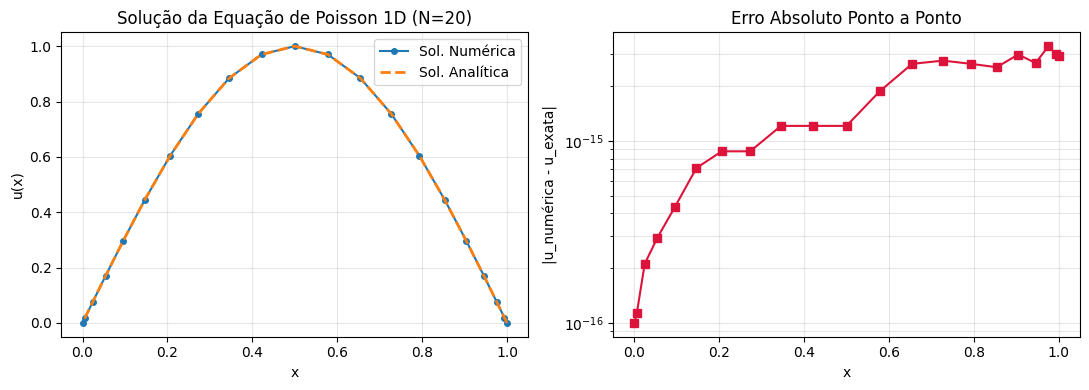

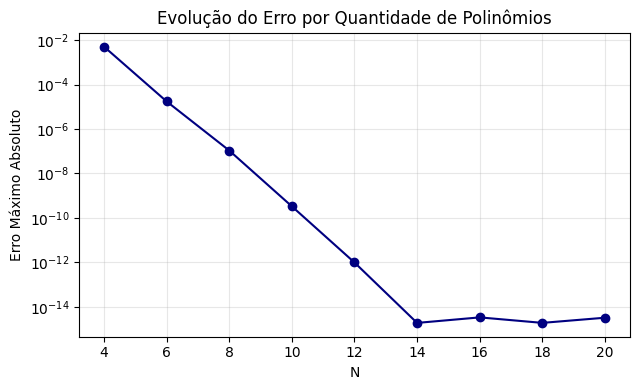

In [2]:
# =============================================================
# Equação de Poisson 1D — Método Espectral Galerkin-colocação
# ∂²u/∂x² = f(x),  u(a) = u_L,  u(b) = u_R
# =============================================================


# -------------------------------------------------------------
# parâmetros e pontos de colocação
# -------------------------------------------------------------
N     = 20          # grau do polinômio (N+1 pontos)
a, b  = 0.0, 1.0    # domínio físico
u_L   = 0.0         # u(a)
u_R   = 0.0         # u(b)

# pontos Gauss-Lobatto-Chebyshev em [-1, 1] (ordem decrescente: ξ_0 = 1 → ξ_N = -1)
j   = np.arange(N + 1)
xi  = np.cos(np.pi * j / N)

# Mapeamento afim para [a, b]
x   = 0.5 * (a + b) + 0.5 * (b - a) * xi

# -------------------------------------------------------------
# matriz de diferenciação espectral
# -------------------------------------------------------------
c       = np.ones(N + 1)
c[0]    = 2.0
c[-1]   = 2.0
c       = c * ((-1.0) ** j)

X       = np.tile(xi, (N + 1, 1)).T
dX      = X - X.T
D_ref   = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
D_ref  -= np.diag(D_ref.sum(axis=1))

scale   = 2.0 / (b - a)
D       = scale * D_ref
D2      = D @ D

# -------------------------------------------------------------
# termo fonte e solução analítica (caso de teste)
# -------------------------------------------------------------
# u(x) = sin(pi x)  →  u'' = -pi² sin(pi x)
f       = -(np.pi ** 2) * np.sin(np.pi * x)
u_exata = np.sin(np.pi * x)

# -------------------------------------------------------------
# condições de contorno e solução analítica
# -------------------------------------------------------------
A       = D2.copy()
rhs     = f.copy()

A[0, :]  = 0.0;  A[0, 0]  = 1.0;  rhs[0]  = u_R   # x = b
A[N, :]  = 0.0;  A[N, N]  = 1.0;  rhs[N]  = u_L   # x = a

u = solve(A, rhs)

# -------------------------------------------------------------
# diagnóstico
# -------------------------------------------------------------
erro    = norm(u - u_exata, ord=np.inf)
residuo = norm((D2 @ u - f)[1:N], ord=np.inf)

print("=" * 55)
print(f"N = {N}  |  Condições de Contorno = [{a}, {b}]")
print(f"Erro Absoluto Global: {erro:.3e}")
print("=" * 55)

# -------------------------------------------------------------
# visualização
# -------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(x, u, "o-", label="Sol. Numérica", ms=4)
ax[0].plot(x, u_exata, "--", label="Sol. Analítica", lw=2)
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x)")
ax[0].set_title(f"Solução da Equação de Poisson 1D (N={N})")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].semilogy(x, np.abs(u - u_exata) + 1e-16, "s-", color="crimson")
ax[1].set_xlabel("x"); ax[1].set_ylabel("|u_numérica - u_exata|")
ax[1].set_title("Erro Absoluto Ponto a Ponto")
ax[1].grid(which="both", alpha=0.3)

plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# convergência espectral: erro vs. N
# -------------------------------------------------------------
Ns, errs = np.arange(4, N + 1, 2), []
for Ni in Ns:
    ji  = np.arange(Ni + 1)
    xii = np.cos(np.pi * ji / Ni)
    xi_phys = 0.5 * (a + b) + 0.5 * (b - a) * xii

    ci      = np.ones(Ni + 1); ci[0] = 2.0; ci[-1] = 2.0
    ci     *= ((-1.0) ** ji)
    Xi      = np.tile(xii, (Ni + 1, 1)).T
    dXi     = Xi - Xi.T
    Di      = np.outer(ci, 1.0 / ci) / (dXi + np.eye(Ni + 1))
    Di     -= np.diag(Di.sum(axis=1))
    Di     *= 2.0 / (b - a)
    D2i     = Di @ Di

    fi      = -(np.pi ** 2) * np.sin(np.pi * xi_phys)
    Ai      = D2i.copy(); bi = fi.copy()
    Ai[0, :] = 0.0; Ai[0, 0] = 1.0; bi[0] = u_R
    Ai[Ni, :] = 0.0; Ai[Ni, Ni] = 1.0; bi[Ni] = u_L

    ui      = solve(Ai, bi)
    errs.append(norm(ui - np.sin(np.pi * xi_phys), ord=np.inf))

plt.figure(figsize=(6.5, 4))
plt.semilogy(Ns, errs, "o-", color="navy")
plt.xlabel("N"); plt.ylabel("Erro Máximo Absoluto")
plt.title("Evolução do Erro por Quantidade de Polinômios")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

N = 20 por direção  |  Pontos da Malha Numérica = 9261
Erro Absoluto Global: 4.643e-12


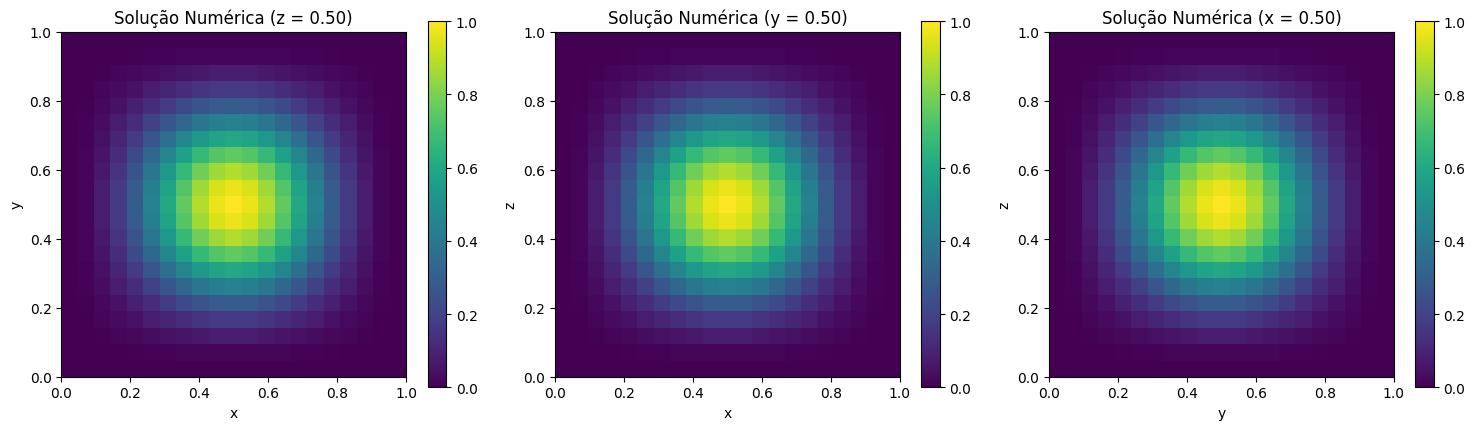

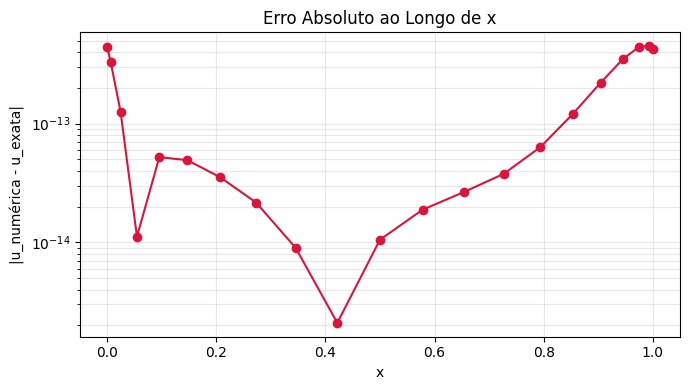

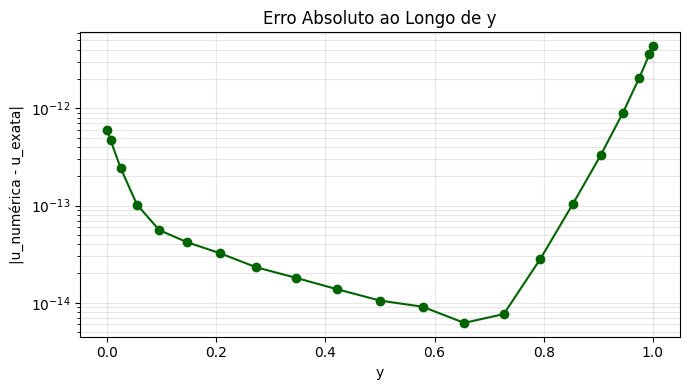

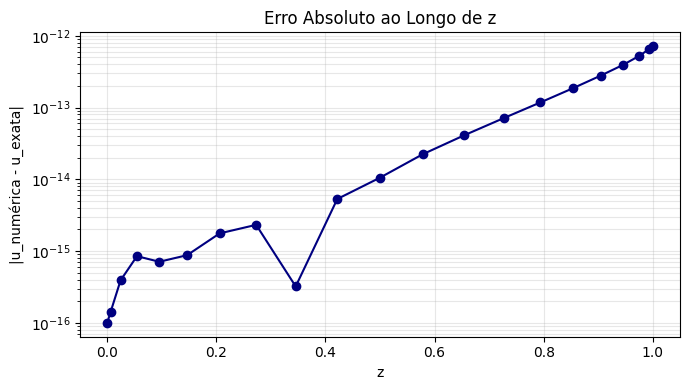

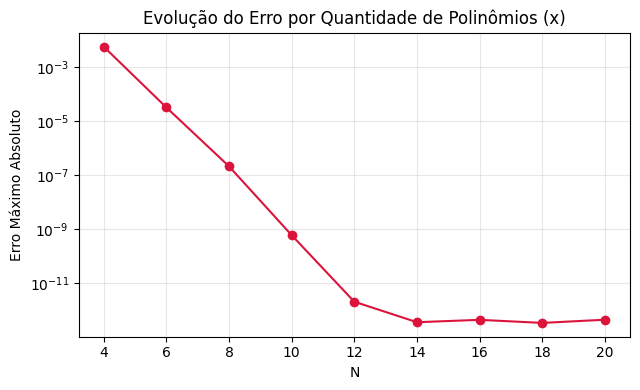

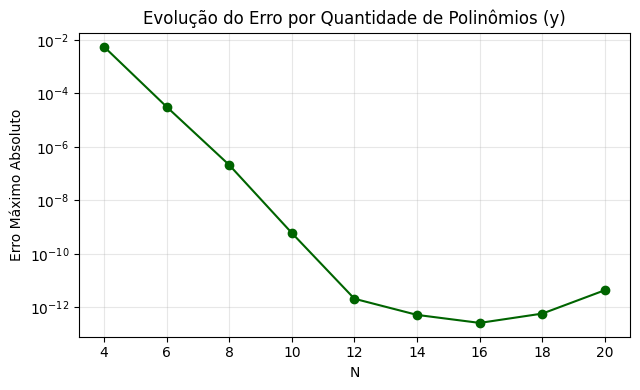

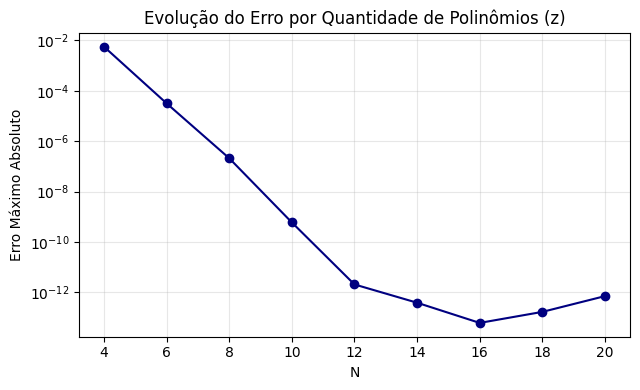

In [3]:
# =============================================================
# Equação de Poisson 3D — Método Espectral Galerkin-colocação
# ∇²u = f(x,y,z),  u = u_bc em ∂Ω
# =============================================================

# -------------------------------------------------------------
# parâmetros e pontos de colocação em cada direção
# -------------------------------------------------------------
N              = 20
xmin, xmax     = 0.0, 1.0
ymin, ymax     = 0.0, 1.0
zmin, zmax     = 0.0, 1.0

j    = np.arange(N + 1)
xi   = np.cos(np.pi * j / N)

x    = 0.5 * (xmin + xmax) + 0.5 * (xmax - xmin) * xi
y    = 0.5 * (ymin + ymax) + 0.5 * (ymax - ymin) * xi
z    = 0.5 * (zmin + zmax) + 0.5 * (zmax - zmin) * xi

Xg, Yg, Zg = np.meshgrid(x, y, z, indexing="ij")

# -------------------------------------------------------------
# matriz de diferenciação espectral em 1D
# -------------------------------------------------------------
c       = np.ones(N + 1)
c[0]    = 2.0
c[-1]   = 2.0
c       = c * ((-1.0) ** j)

Xm      = np.tile(xi, (N + 1, 1)).T
dXm     = Xm - Xm.T
D_ref   = np.outer(c, 1.0 / c) / (dXm + np.eye(N + 1))
D_ref  -= np.diag(D_ref.sum(axis=1))

Dx      = (2.0 / (xmax - xmin)) * D_ref
Dy      = (2.0 / (ymax - ymin)) * D_ref
Dz      = (2.0 / (zmax - zmin)) * D_ref

D2x     = Dx @ Dx
D2y     = Dy @ Dy
D2z     = Dz @ Dz

# -------------------------------------------------------------
# laplaciano 3D
# -------------------------------------------------------------
I       = np.eye(N + 1)
Lap     = (np.kron(np.kron(D2x, I), I)
         + np.kron(np.kron(I, D2y), I)
         + np.kron(np.kron(I, I), D2z))

# -------------------------------------------------------------
# termo fonte e solução analítica (caso de teste)
# u = sin(πx) sin(πy) sin(πz)  →  ∇²u = -3π² u
# -------------------------------------------------------------
f       = -3.0 * (np.pi ** 2) * np.sin(np.pi * Xg) * np.sin(np.pi * Yg) * np.sin(np.pi * Zg)
u_exata = np.sin(np.pi * Xg) * np.sin(np.pi * Yg) * np.sin(np.pi * Zg)

f_flat       = f.ravel(order="F")
u_exata_flat = u_exata.ravel(order="F")

# -------------------------------------------------------------
# condições de contorno de Dirichlet homogêneas (u = 0 em ∂Ω)
# -------------------------------------------------------------
A    = Lap.copy()
rhs  = f_flat.copy()

mask_bc = np.zeros((N + 1, N + 1, N + 1), dtype=bool)
mask_bc[0, :, :] = True;  mask_bc[-1, :, :] = True
mask_bc[:, 0, :] = True;  mask_bc[:, -1, :] = True
mask_bc[:, :, 0] = True;  mask_bc[:, :, -1] = True
idx_bc = np.where(mask_bc.ravel(order="F"))[0]

A[idx_bc, :]      = 0.0
A[idx_bc, idx_bc] = 1.0
rhs[idx_bc]       = 0.0

# -------------------------------------------------------------
# solução do sistema linear
# -------------------------------------------------------------
u_flat = solve(A, rhs)
u      = u_flat.reshape((N + 1, N + 1, N + 1), order="F")

# -------------------------------------------------------------
# diagnóstico
# -------------------------------------------------------------
erro    = norm(u_flat - u_exata_flat, ord=np.inf)
residuo = norm((Lap @ u_flat - f_flat)[~mask_bc.ravel(order="F")], ord=np.inf)

print("=" * 55)
print(f"N = {N} por direção  |  Pontos da Malha Numérica = {(N+1)**3}")
print(f"Erro Absoluto Global: {erro:.3e}")
print("=" * 55)

# -------------------------------------------------------------
# visualização da solução numérica em cortes centrais
# -------------------------------------------------------------
k_mid = N // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

im0 = axes[0].imshow(u[:, :, k_mid].T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax], cmap="viridis")
axes[0].set_title(f"Solução Numérica (z = {z[k_mid]:.2f})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u[:, k_mid, :].T, origin="lower",
                     extent=[xmin, xmax, zmin, zmax], cmap="viridis")
axes[1].set_title(f"Solução Numérica (y = {y[k_mid]:.2f})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("z")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(u[k_mid, :, :].T, origin="lower",
                     extent=[ymin, ymax, zmin, zmax], cmap="viridis")
axes[2].set_title(f"Solução Numérica (x = {x[k_mid]:.2f})")
axes[2].set_xlabel("y"); axes[2].set_ylabel("z")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout(); plt.show()

# -----------------------------------------------------------------------------
# visualização do campo u(x,y,z) com cortes apenas na direção z
# -----------------------------------------------------------------------------

Ng = 60
xg = np.linspace(xmin, xmax, Ng)
yg = np.linspace(ymin, ymax, Ng)
zg = np.linspace(zmin, zmax, Ng)
Xgr, Ygr, Zgr = np.meshgrid(xg, yg, zg, indexing="ij")

interp_u = RegularGridInterpolator((x, y, z), u, method="linear",
                                   bounds_error=False, fill_value=0.0)
Ugrid = interp_u(np.stack([Xgr.ravel(), Ygr.ravel(), Zgr.ravel()], axis=-1)
                 ).reshape(Ng, Ng, Ng)

# níveis de z nos quais queremos ver o potencial no plano xy
z_levels = [0.15, 0.35, 0.5, 0.65, 0.85]
kz_list  = [int(round(zl * (Ng - 1))) for zl in z_levels]

fig = go.Figure()

for i, kz in enumerate(kz_list):
    fig.add_trace(go.Surface(
        x=Xgr[:, :, kz],
        y=Ygr[:, :, kz],
        z=np.full((Ng, Ng), zg[kz]),
        surfacecolor=Ugrid[:, :, kz],
        colorscale="Viridis",
        cmin=Ugrid.min(), cmax=Ugrid.max(),
        showscale=(i == len(kz_list) - 1),
        colorbar=dict(title="u(x,y)", x=1.02) if i == len(kz_list) - 1 else None,
        opacity=0.95,
        name=f"z = {zg[kz]:.2f}",
    ))

fig.update_layout(
    title=f"Solução da Equação de Poisson 3D (N={N})",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="z",
        xaxis=dict(range=[xmin, xmax]),
        yaxis=dict(range=[ymin, ymax]),
        zaxis=dict(range=[zmin, zmax]),
        aspectmode="cube",
    ),
    width=850, height=750,
)

fig.show()
# -------------------------------------------------------------
# erros absolutos ponto a ponto — separados por eixo (x, y, z)
# -------------------------------------------------------------
err3d = np.abs(u - u_exata)

plt.figure(figsize=(7, 4))
plt.semilogy(x, err3d[:, k_mid, k_mid] + 1e-16, "o-", color="crimson")
plt.xlabel("x"); plt.ylabel("|u_numérica - u_exata|")
plt.title("Erro Absoluto ao Longo de x")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(y, err3d[k_mid, :, k_mid] + 1e-16, "o-", color="darkgreen")
plt.xlabel("y"); plt.ylabel("|u_numérica - u_exata|")
plt.title("Erro Absoluto ao Longo de y")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(z, err3d[k_mid, k_mid, :] + 1e-16, "o-", color="navy")
plt.xlabel("z"); plt.ylabel("|u_numérica - u_exata|")
plt.title("Erro Absoluto ao Longo de z")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# convergência espectral — erro vs. N, separado por eixo (x, y, z)
# -------------------------------------------------------------
Ns = np.arange(4, N + 1, 2)
errs_x, errs_y, errs_z = [], [], []

for Ni in Ns:
    ji  = np.arange(Ni + 1)
    xii = np.cos(np.pi * ji / Ni)
    xi_phys = 0.5 * (xmin + xmax) + 0.5 * (xmax - xmin) * xii

    ci      = np.ones(Ni + 1); ci[0] = 2.0; ci[-1] = 2.0
    ci     *= ((-1.0) ** ji)
    Xi      = np.tile(xii, (Ni + 1, 1)).T
    dXi     = Xi - Xi.T
    Di      = np.outer(ci, 1.0 / ci) / (dXi + np.eye(Ni + 1))
    Di     -= np.diag(Di.sum(axis=1))
    Di     *= 2.0 / (xmax - xmin)
    D2i     = Di @ Di

    Ii      = np.eye(Ni + 1)
    Lapi    = (np.kron(np.kron(D2i, Ii), Ii)
             + np.kron(np.kron(Ii, D2i), Ii)
             + np.kron(np.kron(Ii, Ii), D2i))

    Xg_i, Yg_i, Zg_i = np.meshgrid(xi_phys, xi_phys, xi_phys, indexing="ij")
    fi      = -3.0 * (np.pi ** 2) * np.sin(np.pi * Xg_i) * np.sin(np.pi * Yg_i) * np.sin(np.pi * Zg_i)
    fi_flat = fi.ravel(order="F")
    ue_flat = fi_flat / (-3.0 * np.pi ** 2)

    mask_i  = np.zeros((Ni + 1, Ni + 1, Ni + 1), dtype=bool)
    mask_i[0, :, :] = True;  mask_i[-1, :, :] = True
    mask_i[:, 0, :] = True;  mask_i[:, -1, :] = True
    mask_i[:, :, 0] = True;  mask_i[:, :, -1] = True
    idx_i   = np.where(mask_i.ravel(order="F"))[0]

    Ai      = Lapi.copy(); bi = fi_flat.copy()
    Ai[idx_i, :]     = 0.0
    Ai[idx_i, idx_i] = 1.0
    bi[idx_i]        = 0.0

    ui_flat = solve(Ai, bi)
    ui      = ui_flat.reshape((Ni + 1, Ni + 1, Ni + 1), order="F")
    ue      = ue_flat.reshape((Ni + 1, Ni + 1, Ni + 1), order="F")
    erri    = np.abs(ui - ue)

    k = Ni // 2
    errs_x.append(np.max(erri[:, k, k]))
    errs_y.append(np.max(erri[k, :, k]))
    errs_z.append(np.max(erri[k, k, :]))

# -------- erro vs. N ao longo de x --------
plt.figure(figsize=(6.5, 4))
plt.semilogy(Ns, errs_x, "o-", color="crimson")
plt.xlabel("N"); plt.ylabel("Erro Máximo Absoluto")
plt.title("Evolução do Erro por Quantidade de Polinômios (x)")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# -------- erro vs. N ao longo de y --------
plt.figure(figsize=(6.5, 4))
plt.semilogy(Ns, errs_y, "o-", color="darkgreen")
plt.xlabel("N"); plt.ylabel("Erro Máximo Absoluto")
plt.title("Evolução do Erro por Quantidade de Polinômios (y)")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# -------- erro vs. N ao longo de z --------
plt.figure(figsize=(6.5, 4))
plt.semilogy(Ns, errs_z, "o-", color="navy")
plt.xlabel("N"); plt.ylabel("Erro Máximo Absoluto")
plt.title("Evolução do Erro por Quantidade de Polinômios (z)")
plt.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()